In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('data/WWF_data_aggregated.csv')
df

df = df[df['region'].isin(['Horn of Africa', "South America", 'Arctic'])] # Only regions of interest
df

,event_id,date,year,country,region,latitude,longitude,violence_score
156,"alaska1536, alaska1549",6/12/2000,2000,USA,Arctic,58.423992,-135.972736,1
157,"alaska9239, arctic15738, alaska12045",10/26/2000,2000,USA,Arctic,57.792554,-152.368966,2
158,arctic6289,9/5/2000,2000,USA,Arctic,61.657229,-177.157513,2
159,arctic6385,10/12/2000,2000,USA,Arctic,63.127598,-173.711853,2
160,"alaska1535, alaska9188",8/1/2000,2000,USA,Arctic,62.338357,-175.525358,2
...,...,...,...,...,...,...,...,...
1053,ECU_e052,12/20/2020,2020,Ecuador,South America,-2.489000,-81.290000,1
1054,ECU_e056,12/21/2020,2020,Ecuador,South America,-2.731000,-81.011000,1
1055,ECU_e053,11/19/2021,2021,Ecuador,South America,-3.151000,-80.503000,3
1056,ECU_e054,4/20/2022,2022,Ecuador,South America,-3.163000,-80.434000,2


## Data Cleaning

In [41]:
# conflicts by region and year 
regional_data = df.groupby(['year', 'region'])['violence_score'].sum().reset_index(name='num_conflicts')

# conflicts by country and year
country_data = df.groupby(['region', 'country', 'year'])['violence_score'].count().reset_index(name='num_conflicts')
country_data['num_conflicts'].sum() # ensures right count of data

country_data

,region,country,year,num_conflicts
0,Arctic,Canada,2004,1
1,Arctic,Canada,2009,2
2,Arctic,Canada,2010,1
3,Arctic,Canada,2012,1
4,Arctic,Canada,2018,1
...,...,...,...,...
182,South America,Ecuador,2017,3
183,South America,Ecuador,2019,1
184,South America,Ecuador,2020,4
185,South America,Ecuador,2021,1


## Exploratory Data Analysis

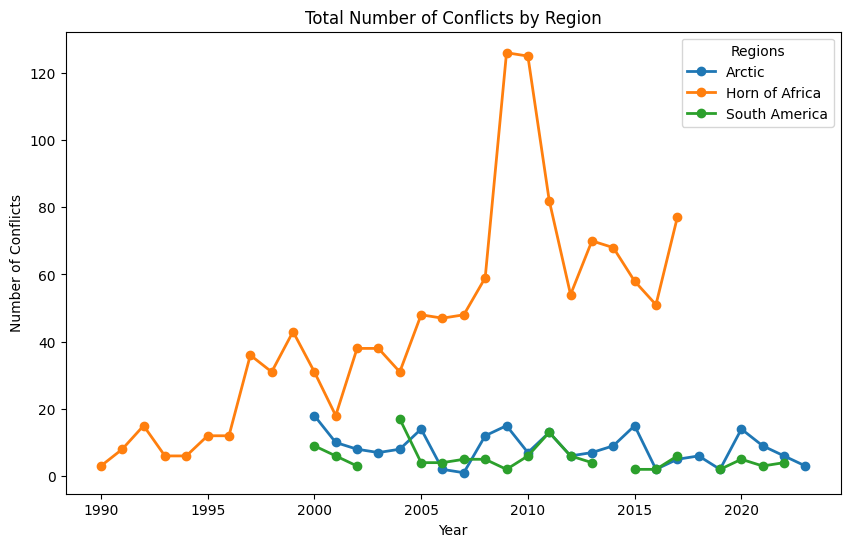

In [ ]:
#plot count of conflicts each year for each region


# Pivot the data so years are the index and regions are the columns
plot_data = regional_data.pivot(index='year', columns='region', values='num_conflicts')

plt.figure(figsize=(10, 6))

# Loop through each column (region) to plot a line
for region in plot_data.columns:
    plt.plot(plot_data.index, plot_data[region], marker='o', linewidth=2, label=region)

plt.title('Total Number of Conflicts by Region')
plt.xlabel('Year')
plt.ylabel('Number of Conflicts')

plt.legend(title='Regions', loc='upper right')